In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')




Mounted at /content/drive


In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
import glob

# ==========================================
# 1. CLAHE TRANSFORM
# ==========================================
class ApplyCLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img_np = np.array(img)
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        clahe_img = self.clahe.apply(gray)
        clahe_rgb = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(clahe_rgb)

# -------------------------------
# Parameters & Transforms
# -------------------------------
# 🚨 UPDATE THIS to the master folder containing all 10,000 images 🚨
data_dir ="/content/drive/MyDrive/output_folder/full_data_fuse/images"

target_cols = ["Atelectasis", "Cardiomegaly", "Edema", "Lung Opacity", "No Finding", "Pleural Effusion"]
num_classes = len(target_cols)
batch_size = 32
num_epochs = 50 # We can safely use 50 now because Early Stopping will catch it!
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
# 🚨 TRAINING TRANSFORMS (With Augmentation to prevent memorization)
train_transform = transforms.Compose([
    ApplyCLAHE(clip_limit=2.0, tile_grid_size=(8, 8)),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))
])

# 🚨 VALIDATION TRANSFORMS (Clean images for accurate testing)
val_transform = transforms.Compose([
    ApplyCLAHE(clip_limit=2.0, tile_grid_size=(8, 8)),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# -------------------------------
# 2. LOAD VAULT & MAP IMAGES
# -------------------------------
print("Loading approved FULL Training CSV...")
train_csv_path = "/content/drive/MyDrive/output_folder/full_data_fuse/TRAIN_fulllabels.csv"
train_df_full = pd.read_csv(train_csv_path)

for col in target_cols:
    train_df_full[col] = pd.to_numeric(train_df_full[col], errors="coerce").fillna(0).clip(0, 1)

print("Scanning large image folder...")
all_image_paths = glob.glob(os.path.join(data_dir, '**', '*.*'), recursive=True)
image_path_dict = {os.path.basename(p).split('.')[0]: p for p in all_image_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))}

train_df_full['image_exists'] = train_df_full['hadm_id'].apply(lambda x: str(x).split('.')[0] in image_path_dict)
train_df_full = train_df_full[train_df_full['image_exists'] == True].copy().reset_index(drop=True)

# 🚨 THE SCIENTIFIC SPLIT 🚨
train_df, val_df = train_test_split(train_df_full, test_size=0.15, random_state=42)
print(f"✅ Training on {len(train_df)} images. Validating on {len(val_df)} images.")

# -------------------------------
# 3. CALCULATE MULTI-LABEL WEIGHTS (On Train Only!)
# -------------------------------
pos_counts = train_df[target_cols].sum(axis=0).values
neg_counts = len(train_df) - pos_counts
pos_weight_raw = np.where(pos_counts > 0, neg_counts / pos_counts, 1.0)
pos_weight_smoothed = np.sqrt(pos_weight_raw).astype(np.float32)

pos_weight_tensor = torch.tensor(pos_weight_smoothed, dtype=torch.float32).to(device)
print(f"Smoothed Positive Weights per class: {pos_weight_smoothed}")

# -------------------------------
# 4. CUSTOM MULTI-LABEL DATASET & LOADERS
# -------------------------------
class MultiLabelXRayDataset(Dataset):
    def __init__(self, df, target_cols, image_dict, transform=None):
        self.df = df.reset_index(drop=True)
        self.target_cols = target_cols
        self.image_dict = image_dict
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patient_id = str(row['hadm_id']).split('.')[0]
        img_path = self.image_dict[patient_id]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        labels = row[self.target_cols].values.astype(np.float32)
        return image, torch.tensor(labels, dtype=torch.float32)

train_dataset = MultiLabelXRayDataset(train_df, target_cols, image_path_dict, transform=train_transform)
val_dataset = MultiLabelXRayDataset(val_df, target_cols, image_path_dict, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# -------------------------------
# 5. MODEL (DenseNet121)
# -------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, num_classes)
model = model.to(device)

# 🚨 WEIGHTED FOCAL LOSS 🚨
class WeightedFocalLoss(nn.Module):
    def __init__(self, pos_weight, alpha=0.50, gamma=2.0):
        super(WeightedFocalLoss, self).__init__()
        self.pos_weight = pos_weight
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none', pos_weight=self.pos_weight)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

criterion = WeightedFocalLoss(pos_weight=pos_weight_tensor, alpha=0.50, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)

# -------------------------------
# 6. TRAINING LOOP WITH EARLY STOPPING
# -------------------------------
print(f"\n--- Training Grand Champion Image Model on {device} ---")

best_val_loss = float('inf')
patience = 7 # If it doesn't improve for 7 epochs, kill the loop
trigger_times = 0
best_model_path = "/content/densenet_multi_label_FULL_best.pth"

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0

    for imgs, labels_batch in train_loader:
        imgs, labels_batch = imgs.to(device), labels_batch.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, labels_batch in val_loader:
            imgs, labels_batch = imgs.to(device), labels_batch.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels_batch)
            val_loss += loss.item() * imgs.size(0)

    val_loss = val_loss / len(val_loader.dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # --- EARLY STOPPING LOGIC ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        trigger_times += 1
        print(f"⚠️ Validation loss did not improve. Patience: {trigger_times}/{patience}")
        if trigger_times >= patience:
            print(f"\n🛑 EARLY STOPPING TRIGGERED AT EPOCH {epoch+1}!")
            print(f"The model peaked at a Validation Loss of {best_val_loss:.4f}.")
            print("Training halted to prevent memorization and preserve generalization.")
            break

print(f"\n✅ Peak Performance Image Model saved to: {best_model_path}")

cuda
Loading approved FULL Training CSV...
Scanning large image folder...
✅ Training on 6159 images. Validating on 1088 images.
Smoothed Positive Weights per class: [1.4653205 1.2908268 1.854001  1.372872  2.3667037 1.251499 ]

--- Training Grand Champion Image Model on cuda ---
Epoch [1/50] | Train Loss: 0.1295 | Val Loss: 0.1255
Epoch [2/50] | Train Loss: 0.1222 | Val Loss: 0.1218
Epoch [3/50] | Train Loss: 0.1181 | Val Loss: 0.1197
Epoch [4/50] | Train Loss: 0.1150 | Val Loss: 0.1184
Epoch [5/50] | Train Loss: 0.1130 | Val Loss: 0.1170
Epoch [6/50] | Train Loss: 0.1114 | Val Loss: 0.1172
⚠️ Validation loss did not improve. Patience: 1/7
Epoch [7/50] | Train Loss: 0.1100 | Val Loss: 0.1161
Epoch [8/50] | Train Loss: 0.1085 | Val Loss: 0.1160
Epoch [9/50] | Train Loss: 0.1068 | Val Loss: 0.1158
Epoch [10/50] | Train Loss: 0.1060 | Val Loss: 0.1155
Epoch [11/50] | Train Loss: 0.1047 | Val Loss: 0.1158
⚠️ Validation loss did not improve. Patience: 1/7
Epoch [12/50] | Train Loss: 0.1034 

In [ ]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torch.optim.lr_scheduler as lr_scheduler

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)


# ==========================================
# 1. DATA PROCESSING (STRICT VAULT SYSTEM)
# ==========================================
print("Loading Synchronized Multi-Label Tabular Data...")
train_csv_path = "/content/drive/MyDrive/output_folder/full_data_fuse/LABS_TRAIN_SYNCED.csv"
test_csv_path = "/content/drive/MyDrive/output_folder/full_data_fuse/LABS_TEST_SYNCED.csv"

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

train_df['is_train'] = 1
test_df['is_train'] = 0

combined_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

VALID_LABELS = {"High", "Normal", "Low", "Missing"}
MISSING_TOKENS = {"", " ", "nan", "na", "n/a", "none", "null", "missing"}

def clean_lab_label(value):
    if pd.isna(value): return "Missing"
    s = str(value).strip().lower()
    if s in MISSING_TOKENS: return "Missing"
    s = s.title()
    if s in VALID_LABELS: return s
    return "Missing"

target_cols = ["Atelectasis", "Cardiomegaly", "Edema", "Lung Opacity", "No Finding", "Pleural Effusion"]
label_cols = [c for c in combined_df.columns if c.endswith("_label")]
z_cols = [c for c in combined_df.columns if c.endswith("_z")]

X_labels = combined_df[label_cols].copy()
for col in label_cols:
    X_labels[col] = X_labels[col].apply(clean_lab_label)

X_labels_oh = pd.get_dummies(X_labels, columns=label_cols, dtype=np.float32)

X_z = combined_df[z_cols].astype(np.float32)
X_z_missing = X_z.isna().astype(np.float32)
X_z_missing.columns = [f"{c}_missing" for c in z_cols]
X_z_filled = X_z.fillna(0.0)

X_combined = pd.concat([X_labels_oh, X_z_filled, X_z_missing, combined_df[['is_train']]], axis=1)

y_combined = combined_df[target_cols].copy().fillna(0)
for col in target_cols:
    y_combined[col] = pd.to_numeric(y_combined[col], errors="coerce").fillna(0).clip(0, 1)
y_combined['is_train'] = combined_df['is_train']

# SEPARATE BACK INTO TRAIN AND TEST
X_train_full = X_combined[X_combined['is_train'] == 1].drop('is_train', axis=1)
X_test_df = X_combined[X_combined['is_train'] == 0].drop('is_train', axis=1)

y_train_full = y_combined[y_combined['is_train'] == 1].drop('is_train', axis=1).values.astype(np.float32)
y_test = y_combined[y_combined['is_train'] == 0].drop('is_train', axis=1).values.astype(np.float32)

# 🚨 THE ANTI-OVERFITTING SPLIT 🚨
# Carve out 15% of the training data purely to monitor overfitting (Test Vault remains untouched!)
X_train_df, X_val_df, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42
)

print(f"Training on {len(X_train_df)} patients.")
print(f"Validating (Early Stop Monitor) on {len(X_val_df)} patients.")
print(f"Final Test Vault holds {len(X_test_df)} patients.")

# Scale the data (Fit ONLY on the pure training subset)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df).astype(np.float32)
X_val = scaler.transform(X_val_df).astype(np.float32)
X_test = scaler.transform(X_test_df).astype(np.float32)

# To PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# DataLoaders
BATCH_SIZE = 128
train_dl = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)


# ==========================================
# 2. ADVANCED MODEL ARCHITECTURE
# ==========================================
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.bn1 = nn.BatchNorm1d(dim)
        self.fc2 = nn.Linear(dim, dim)
        self.bn2 = nn.BatchNorm1d(dim)
        self.drop = nn.Dropout(dropout)
        self.gelu = nn.GELU()

    def forward(self, x):
        residual = x
        out = self.gelu(self.bn1(self.fc1(x)))
        out = self.drop(out)
        out = self.bn2(self.fc2(out))
        out += residual
        return self.gelu(out)

class AdvancedBloodNet(nn.Module):
    def __init__(self, input_dim, num_targets):
        super().__init__()
        self.entry = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3)
        )
        self.res1 = ResidualBlock(256, dropout=0.3)
        self.res2 = ResidualBlock(256, dropout=0.3)

        self.compression = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_targets)
        )

    def forward(self, x):
        return self.compression(self.res2(self.res1(self.entry(x))))

# ==========================================
# 🚨 WEIGHTED FOCAL LOSS 🚨
# ==========================================
class WeightedFocalLoss(nn.Module):
    def __init__(self, pos_weight, alpha=0.50, gamma=2.0):
        super(WeightedFocalLoss, self).__init__()
        self.pos_weight = pos_weight
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        # BCEWithLogits natively handles the positive weights for imbalance
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none', pos_weight=self.pos_weight)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

input_dim = X_train.shape[1]
num_targets = len(target_cols)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AdvancedBloodNet(input_dim, num_targets).to(device)

# Multi-Label Weights Calculation
pos_counts = y_train.sum(axis=0)
neg_counts = len(y_train) - pos_counts
pos_weight_raw = np.where(pos_counts > 0, neg_counts / pos_counts, 1.0)
pos_weight_np = np.sqrt(pos_weight_raw).astype(np.float32)
pos_weight = torch.tensor(pos_weight_np, dtype=torch.float32, device=device)

criterion = WeightedFocalLoss(pos_weight=pos_weight, alpha=0.50, gamma=2.0)

EPOCHS = 150
MAX_LR = 1e-3 # Lowered slightly for stability with Focal Loss
optimizer = torch.optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=1e-3)
steps_per_epoch = len(train_dl)
scheduler = lr_scheduler.OneCycleLR(
    optimizer, max_lr=MAX_LR, steps_per_epoch=steps_per_epoch, epochs=EPOCHS
)

# ==========================================
# 4. TRAINING LOOP WITH EARLY STOPPING
# ==========================================
print("\n--- Training Advanced Blood Model ---")

best_val_loss = float('inf')
patience = 15 # Allow 15 epochs of no improvement before killing it
trigger_times = 0
best_model_path = "blood_net_FULL_best.pth"

for epoch in range(1, EPOCHS + 1):
    # --- TRAIN PHASE ---
    model.train()
    running_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        scheduler.step()
        running_loss += loss.item() * len(xb)
    avg_train_loss = running_loss / len(X_train_df)

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * len(xb)
    avg_val_loss = val_loss / len(X_val_df)

    # Print every 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # --- EARLY STOPPING LOGIC ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        trigger_times = 0
        torch.save(model.state_dict(), best_model_path) # Save the absolute best weights
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"\n🛑 Early Stopping Triggered at Epoch {epoch}! Validation loss stopped improving.")
            print("Restoring best weights to prevent overfitting.")
            break

# ==========================================
# 5. MULTI-LABEL EVALUATION ON VAULT
# ==========================================
# Load the best weights captured during training
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

with torch.no_grad():
    logits = model(X_test_t.to(device))
    probs = torch.sigmoid(logits).cpu().numpy()

y_true = y_test.astype(int)

print("\n========== BLOOD MODEL GRID SEARCH (VAULT TEST) ==========")
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
best_thresh = 0.5
best_macro_f1 = 0.0
best_y_pred = None

print(f"{'Threshold':<10} | {'Exact Acc':<10} | {'Macro F1':<10} | {'Micro F1':<10}")
print("-" * 50)

for thresh in thresholds_to_test:
    y_pred_temp = (probs >= thresh).astype(int)
    acc = accuracy_score(y_true, y_pred_temp)
    macro_f1 = f1_score(y_true, y_pred_temp, average='macro', zero_division=0)
    micro_f1 = f1_score(y_true, y_pred_temp, average='micro', zero_division=0)
    print(f"{thresh:<10.1f} | {acc:<10.3f} | {macro_f1:<10.3f} | {micro_f1:<10.3f}")

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_thresh = thresh
        best_y_pred = y_pred_temp.copy()

print("\n" + "="*65)
print(f"🏆 WINNING THRESHOLD: {best_thresh} (Highest Macro F1)")
print("="*65)

print(f"\n{'Disease':<18} | {'Prec':<6} | {'Rec':<6} | {'F1':<6} | {'AUROC':<6}")
print("-" * 60)
for i, col in enumerate(target_cols):
    precision = precision_score(y_true[:, i], best_y_pred[:, i], zero_division=0)
    recall = recall_score(y_true[:, i], best_y_pred[:, i], zero_division=0)
    f1 = f1_score(y_true[:, i], best_y_pred[:, i], zero_division=0)
    try:
        auc = roc_auc_score(y_true[:, i], probs[:, i])
        auc_text = f"{auc:.3f}"
    except ValueError:
        auc_text = "N/A"

    print(f"{col:<18} | {precision:.3f} | {recall:.3f} | {f1:.3f} | {auc_text}")

Loading Synchronized Multi-Label Tabular Data...
Training on 6159 patients.
Validating (Early Stop Monitor) on 1088 patients.
Final Test Vault holds 1812 patients.

--- Training Advanced Blood Model ---
Epoch 001/150 | Train Loss: 0.1448 | Val Loss: 0.1358
Epoch 010/150 | Train Loss: 0.1270 | Val Loss: 0.1266
Epoch 020/150 | Train Loss: 0.1191 | Val Loss: 0.1269
Epoch 030/150 | Train Loss: 0.1135 | Val Loss: 0.1312

🛑 Early Stopping Triggered at Epoch 31! Validation loss stopped improving.
Restoring best weights to prevent overfitting.

========== BLOOD MODEL GRID SEARCH (VAULT TEST) ==========
Threshold  | Exact Acc  | Macro F1   | Micro F1  
--------------------------------------------------
0.3        | 0.000      | 0.461      | 0.468     
0.4        | 0.003      | 0.468      | 0.481     
0.5        | 0.061      | 0.446      | 0.462     
0.6        | 0.022      | 0.067      | 0.056     
0.7        | 0.000      | 0.000      | 0.000     

🏆 WINNING THRESHOLD: 0.4 (Highest Macro F1)

D

In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
import glob

# ==========================================
# 1. LOAD THE PERFECTLY SYNCED VAULTS
# ==========================================
print("Loading Synchronized Multi-Label Tabular Data...")

train_csv_path =  "/content/drive/MyDrive/output_folder/full_data_fuse/LABS_TRAIN_SYNCED.csv"
test_csv_path  =  "/content/drive/MyDrive/output_folder/full_data_fuse/LABS_TEST_SYNCED.csv"

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

train_df['is_train'] = 1
test_df['is_train'] = 0
combined_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

target_cols = ["Atelectasis", "Cardiomegaly", "Edema", "Lung Opacity", "No Finding", "Pleural Effusion"]
label_cols = [c for c in combined_df.columns if c.endswith("_label")]
z_cols = [c for c in combined_df.columns if c.endswith("_z")]

VALID_LABELS = {"High", "Normal", "Low", "Missing"}
MISSING_TOKENS = {"", " ", "nan", "na", "n/a", "none", "null", "missing"}

def clean_lab_label(value):
    if pd.isna(value): return "Missing"
    s = str(value).strip().lower()
    if s in MISSING_TOKENS: return "Missing"
    s = s.title()
    if s in VALID_LABELS: return s
    return "Missing"

X_labels = combined_df[label_cols].copy()
for col in label_cols: X_labels[col] = X_labels[col].apply(clean_lab_label)
X_labels_oh = pd.get_dummies(X_labels, columns=label_cols, dtype=np.float32)

X_z = combined_df[z_cols].astype(np.float32)
X_z_missing = X_z.isna().astype(np.float32)
X_z_missing.columns = [f"{c}_missing" for c in z_cols]
X_z_filled = X_z.fillna(0.0)

y_df = combined_df[target_cols].copy().fillna(0)
for col in target_cols:
    y_df[col] = pd.to_numeric(y_df[col], errors="coerce").fillna(0).clip(0, 1)

master_processed_df = pd.concat([combined_df[['hadm_id', 'is_train']], X_labels_oh, X_z_filled, X_z_missing, y_df], axis=1)
all_tabular_features = list(X_labels_oh.columns) + list(X_z_filled.columns) + list(X_z_missing.columns)

# ==========================================
# 2. MATCH WITH IMAGES
# ==========================================
image_folder = "/content/drive/MyDrive/output_folder/full_data_fuse/images"

print("Mapping images to patients...")
all_image_paths = glob.glob(os.path.join(image_folder, '**', '*.*'), recursive=True)
image_path_dict = {os.path.basename(p).split('.')[0]: p for p in all_image_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))}

master_processed_df['image_exists'] = master_processed_df['hadm_id'].apply(lambda x: str(x).split('.')[0] in image_path_dict)
final_fusion_df = master_processed_df[master_processed_df['image_exists'] == True].copy()

train_fusion_df = final_fusion_df[final_fusion_df['is_train'] == 1].copy()
test_fusion_df = final_fusion_df[final_fusion_df['is_train'] == 0].copy()

print(f"✅ Ready! Training Fusion on {len(train_fusion_df)} matched patients. Testing on {len(test_fusion_df)} matched patients.")

class ApplyCLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    def __call__(self, img):
        img_np = np.array(img)
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        clahe_img = self.clahe.apply(gray)
        return Image.fromarray(cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB))

class MultimodalDataset(Dataset):
    def __init__(self, df, tabular_features, target_cols, image_dict, transform=None):
        self.df = df.reset_index(drop=True)
        self.tabular_features = tabular_features
        self.target_cols = target_cols
        self.image_dict = image_dict
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patient_id = str(row['hadm_id']).split('.')[0]
        img_path = self.image_dict[patient_id]
        image = Image.open(img_path).convert("RGB")
        if self.transform: image = self.transform(image)
        tab_tensor = torch.tensor(row[self.tabular_features].values.astype(np.float32), dtype=torch.float32)
        label_tensor = torch.tensor(row[self.target_cols].values.astype(np.float32), dtype=torch.float32)
        return image, tab_tensor, label_tensor

fusion_transform = transforms.Compose([
    ApplyCLAHE(clip_limit=2.0, tile_grid_size=(8, 8)),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_loader = DataLoader(MultimodalDataset(train_fusion_df, all_tabular_features, target_cols, image_path_dict, fusion_transform), batch_size=32, shuffle=True)
test_loader = DataLoader(MultimodalDataset(test_fusion_df, all_tabular_features, target_cols, image_path_dict, fusion_transform), batch_size=32, shuffle=False)

# ==========================================
# 3. BASE ARCHITECTURES (The Experts)
# ==========================================
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.bn1 = nn.BatchNorm1d(dim)
        self.fc2 = nn.Linear(dim, dim)
        self.bn2 = nn.BatchNorm1d(dim)
        self.drop = nn.Dropout(dropout)
        self.gelu = nn.GELU()
    def forward(self, x):
        residual = x
        out = self.gelu(self.bn1(self.fc1(x)))
        out = self.drop(out)
        out = self.bn2(self.fc2(out))
        return self.gelu(out + residual)

class AdvancedBloodNet(nn.Module):
    def __init__(self, input_dim, num_targets):
        super().__init__()
        self.entry = nn.Sequential(nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.3))
        self.res1 = ResidualBlock(256, dropout=0.3)
        self.res2 = ResidualBlock(256, dropout=0.3)
        self.compression = nn.Sequential(nn.Linear(256, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.2), nn.Linear(128, num_targets))
    def forward(self, x): return self.compression(self.res2(self.res1(self.entry(x))))

def get_image_model(num_classes):
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model

# ==========================================
# 4. 🚨 THE SOTA UPGRADE: CROSS-ATTENTION FUSION 🚨
# ==========================================
class CrossAttentionFusion(nn.Module):
    def __init__(self, image_model, tabular_model, num_classes=6, embed_dim=256, num_heads=4):
        super().__init__()
        self.image_model = image_model
        self.tabular_model = tabular_model

        # 🚨 FREEZING THE EXPERTS TO PROTECT THEIR WEIGHTS 🚨
        for param in self.image_model.parameters(): param.requires_grad = False
        for param in self.tabular_model.parameters(): param.requires_grad = False

        # 1. Projection Layers: Translate both languages into a shared dimension
        self.img_proj = nn.Linear(1024, embed_dim) # DenseNet outputs 1024
        self.tab_proj = nn.Linear(128, embed_dim)  # BloodNet outputs 128

        # 2. The Cross-Attention Engine (Tabular queries Image)
        self.cross_attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True, dropout=0.3)
        self.layer_norm = nn.LayerNorm(embed_dim)

        # 3. The Final Diagnostic Brain
        self.fusion_head = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, image, tabular):
        # --- THE VISUAL KEY & VALUE (Preserving Spatial Patches) ---
        img_feats = self.image_model.features(image) # Shape: [Batch, 1024, 7, 7]
        img_feats = F.relu(img_feats, inplace=True)

        # Flatten the 7x7 grid into 49 spatial "patches"
        Batch, Channels, Height, Width = img_feats.shape
        img_seq = img_feats.view(Batch, Channels, Height * Width).permute(0, 2, 1) # Shape: [Batch, 49, 1024]

        # Project image features to shared embedding space
        img_seq_proj = self.img_proj(img_seq) # Shape: [Batch, 49, 256]

        # --- THE BIOLOGICAL QUERY ---
        tab_feats = self.tabular_model.entry(tabular)
        tab_feats = self.tabular_model.res1(tab_feats)
        tab_feats = self.tabular_model.res2(tab_feats)
        for layer in self.tabular_model.compression[:-1]:
            tab_feats = layer(tab_feats) # Shape: [Batch, 128]

        # Project tabular features to shared embedding space and add sequence dim
        tab_proj = self.tab_proj(tab_feats).unsqueeze(1) # Shape: [Batch, 1, 256]

        # --- MULTIMODAL CROSS-ATTENTION ---
        # Query = Tabular. Key/Value = Image.
        attn_output, attn_weights = self.cross_attention(
            query=tab_proj,
            key=img_seq_proj,
            value=img_seq_proj
        )

        # Remove the extra sequence dimension [Batch, 1, 256] -> [Batch, 256]
        attn_output = attn_output.squeeze(1)

        # Apply LayerNorm for stability
        fused_features = self.layer_norm(attn_output)

        # --- FINAL PREDICTION ---
        return self.fusion_head(fused_features)

# ==========================================
# 🚨 FOCAL LOSS 🚨
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.50, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss

        if self.reduction == 'mean': return focal_loss.mean()
        elif self.reduction == 'sum': return focal_loss.sum()
        else: return focal_loss

# ==========================================
# 5. INITIALIZE & LOAD EXPERTS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tabular_model = AdvancedBloodNet(len(all_tabular_features), len(target_cols)).to(device)
image_model = get_image_model(len(target_cols)).to(device)

print("\nLoading pre-trained FULL multi-label base models...")
# 🚨 DOUBLE CHECK THESE PATHS MATCH YOUR EARLY STOPPING SAVES 🚨
tabular_model.load_state_dict(torch.load("/content/blood_net_FULL_best.pth", map_location=device))
image_model.load_state_dict(torch.load("/content/densenet_multi_label_FULL_best.pth", map_location=device))

# Instantiate the NEW Cross-Attention architecture
fusion_model = CrossAttentionFusion(image_model, tabular_model, num_classes=len(target_cols)).to(device)

# 🚨 OPTIMIZER: Only trains the new attention layers and head 🚨
optimizer = optim.Adam(filter(lambda p: p.requires_grad, fusion_model.parameters()), lr=0.001, weight_decay=1e-4)

# 🚨 SMART SCHEDULER
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
criterion = FocalLoss(alpha=0.50, gamma=2.0)

# ==========================================
# 6. TRAINING THE SOTA FUSION (With Early Stopping)
# ==========================================
epochs = 30
patience = 4
trigger_times = 0
best_loss = float('inf')
best_fusion_path = "cross_attention_fusion_best.pth"

print(f"\n--- Training SOTA Cross-Attention Fusion Network (Max {epochs} Epochs) ---")
for epoch in range(epochs):
    fusion_model.train()
    running_loss = 0.0
    for imgs, tabs, labels in train_loader:
        imgs, tabs, labels = imgs.to(device), tabs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(fusion_model(imgs, tabs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)

    epoch_loss = running_loss/len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f}")

    scheduler.step(epoch_loss)

    # 🚨 EARLY STOPPING LOGIC 🚨
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        trigger_times = 0
        torch.save(fusion_model.state_dict(), best_fusion_path)
    else:
        trigger_times += 1
        print(f"⚠️ No improvement. Early Stopping Patience: {trigger_times}/{patience}")
        if trigger_times >= patience:
            print("\n🛑 Early Stopping Triggered! The cross-attention layers have peaked.")
            break

# ==========================================
# 7. GRID SEARCH: FIXED THRESHOLD TESTING
# ==========================================
# Load the absolute best fusion weights before testing
fusion_model.load_state_dict(torch.load(best_fusion_path, map_location=device))

print("\n========== SOTA CROSS-ATTENTION: GRID SEARCH ==========")
fusion_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, tabs, labels in test_loader:
        all_preds.append(torch.sigmoid(fusion_model(imgs.to(device), tabs.to(device))).cpu().numpy())
        all_labels.append(labels.numpy())

y_probs = np.vstack(all_preds)
y_true = np.vstack(all_labels)

thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

best_thresh = 0.5
best_macro_f1 = 0.0
best_y_pred = None

print(f"{'Threshold':<10} | {'Exact Acc':<10} | {'Macro F1':<10} | {'Micro F1':<10}")
print("-" * 50)

for thresh in thresholds_to_test:
    y_pred_temp = (y_probs >= thresh).astype(int)
    acc = accuracy_score(y_true, y_pred_temp)
    macro_f1 = f1_score(y_true, y_pred_temp, average='macro', zero_division=0)
    micro_f1 = f1_score(y_true, y_pred_temp, average='micro', zero_division=0)
    print(f"{thresh:<10.1f} | {acc:<10.3f} | {macro_f1:<10.3f} | {micro_f1:<10.3f}")

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_thresh = thresh
        best_y_pred = y_pred_temp.copy()

print("\n" + "="*65)
print(f"🏆 WINNING THRESHOLD: {best_thresh} (Highest Macro F1)")
print("="*65)

print(f"\n{'Disease':<18} | {'Acc':<5} | {'Prec':<5} | {'Rec':<5} | {'F1':<5} | {'AUROC':<5}")
print("-" * 65)
for i, col in enumerate(target_cols):
    acc = accuracy_score(y_true[:, i], best_y_pred[:, i])
    prec = precision_score(y_true[:, i], best_y_pred[:, i], zero_division=0)
    rec = recall_score(y_true[:, i], best_y_pred[:, i], zero_division=0)
    f1 = f1_score(y_true[:, i], best_y_pred[:, i], zero_division=0)
    auroc = roc_auc_score(y_true[:, i], y_probs[:, i]) if len(np.unique(y_true[:, i])) > 1 else 0.0
    print(f"{col:<18} | {acc:.3f} | {prec:.3f} | {rec:.3f} | {f1:.3f} | {auroc:.3f}")

print("\n" + "="*65)
print(f"✅ SOTA MODEL SAVED TO: {best_fusion_path}")
print("="*65)


Loading Synchronized Multi-Label Tabular Data...
Mapping images to patients...
✅ Ready! Training Fusion on 7247 matched patients. Testing on 1812 matched patients.

Loading pre-trained FULL multi-label base models...

--- Training SOTA Cross-Attention Fusion Network (Max 30 Epochs) ---
Epoch [1/30] | Loss: 0.0712
Epoch [2/30] | Loss: 0.0670
Epoch [3/30] | Loss: 0.0654
Epoch [4/30] | Loss: 0.0650
Epoch [5/30] | Loss: 0.0646
Epoch [6/30] | Loss: 0.0643
Epoch [7/30] | Loss: 0.0642
Epoch [8/30] | Loss: 0.0640
Epoch [9/30] | Loss: 0.0637
Epoch [10/30] | Loss: 0.0637
Epoch [11/30] | Loss: 0.0636
Epoch [12/30] | Loss: 0.0632
Epoch [13/30] | Loss: 0.0633
⚠️ No improvement. Early Stopping Patience: 1/4
Epoch [14/30] | Loss: 0.0630
Epoch [15/30] | Loss: 0.0629
Epoch [16/30] | Loss: 0.0628
Epoch [17/30] | Loss: 0.0625
Epoch [18/30] | Loss: 0.0625
⚠️ No improvement. Early Stopping Patience: 1/4
Epoch [19/30] | Loss: 0.0626
⚠️ No improvement. Early Stopping Patience: 2/4
Epoch [20/30] | Loss: 0.062

Rebuilding Data Loaders and Context...
Rebuilding Model Architectures...
Loading saved model weights...
Running dynamic inference on 1812 patients...

Disease            | Image   | Blood   | Fusion 
Atelectasis        | 0.671   | 0.575   | 0.670
Cardiomegaly       | 0.634   | 0.572   | 0.624
Edema              | 0.797   | 0.619   | 0.778
Lung Opacity       | 0.637   | 0.575   | 0.643
No Finding         | 0.819   | 0.663   | 0.793
Pleural Effusion   | 0.773   | 0.605   | 0.774

Generating final dynamic plot...


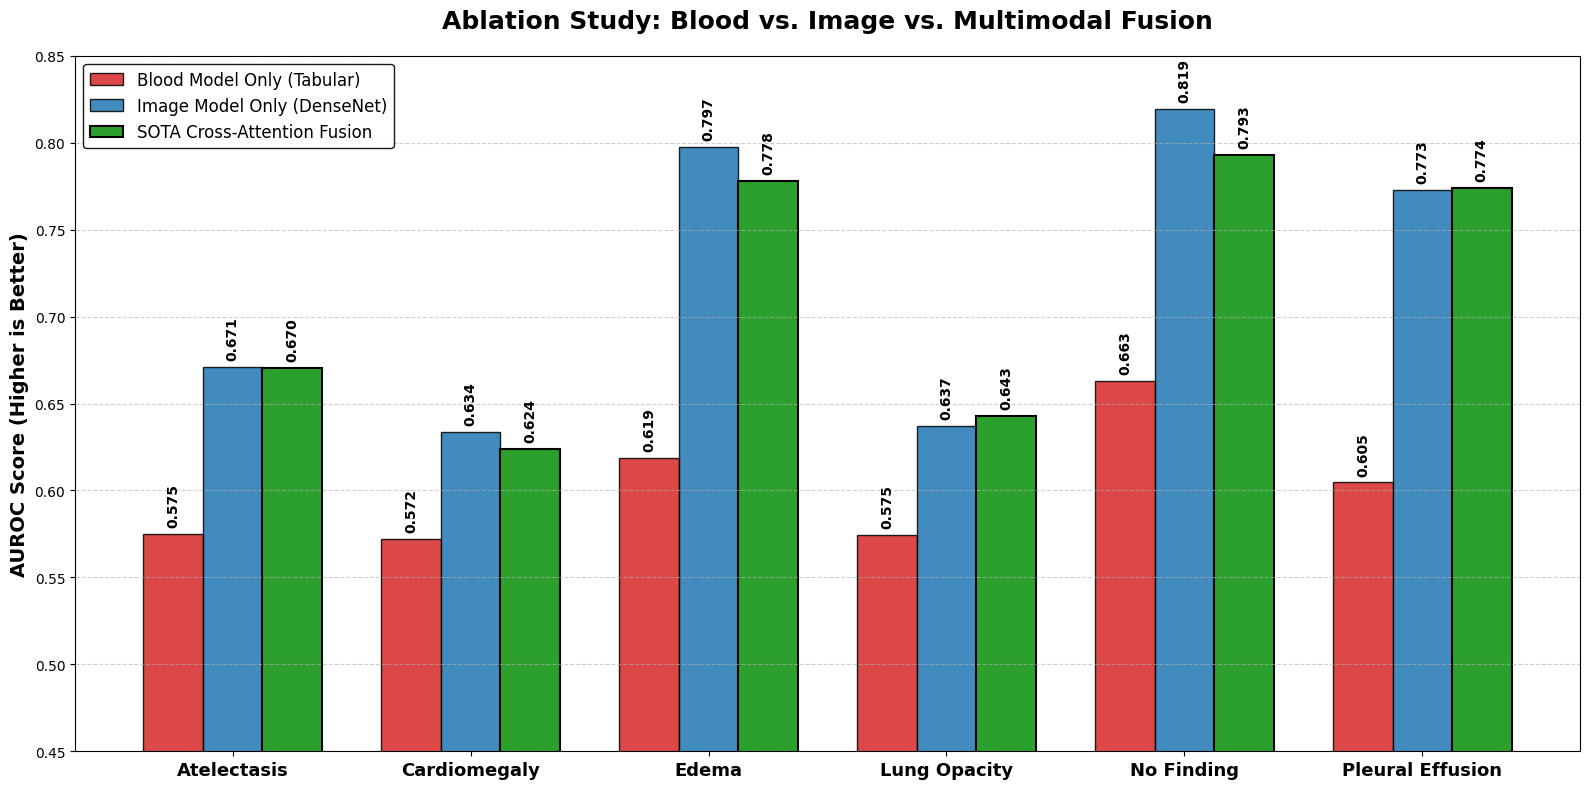


✅ Ablation Study Complete! Image saved as 'Dynamic_Ablation_Study_AUROC.png'


In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import glob

# ==========================================
# 1. REBUILD THE DATA LOADERS (Test Set Only)
# ==========================================
print("Rebuilding Data Loaders and Context...")
train_csv_path = "/content/drive/MyDrive/output_folder/full_data_fuse/LABS_TRAIN_SYNCED.csv"
test_csv_path  = "/content/drive/MyDrive/output_folder/full_data_fuse/LABS_TEST_SYNCED.csv"

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)
train_df['is_train'] = 1
test_df['is_train'] = 0
combined_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

target_cols = ["Atelectasis", "Cardiomegaly", "Edema", "Lung Opacity", "No Finding", "Pleural Effusion"]
label_cols = [c for c in combined_df.columns if c.endswith("_label")]
z_cols = [c for c in combined_df.columns if c.endswith("_z")]

def clean_lab_label(value):
    MISSING_TOKENS = {"", " ", "nan", "na", "n/a", "none", "null", "missing"}
    if pd.isna(value): return "Missing"
    s = str(value).strip().lower()
    if s in MISSING_TOKENS: return "Missing"
    s = s.title()
    if s in {"High", "Normal", "Low", "Missing"}: return s
    return "Missing"

X_labels = combined_df[label_cols].copy()
for col in label_cols: X_labels[col] = X_labels[col].apply(clean_lab_label)
X_labels_oh = pd.get_dummies(X_labels, columns=label_cols, dtype=np.float32)
X_z_filled = combined_df[z_cols].astype(np.float32).fillna(0.0)
X_z_missing = combined_df[z_cols].astype(np.float32).isna().astype(np.float32)
X_z_missing.columns = [f"{c}_missing" for c in z_cols]

y_df = combined_df[target_cols].copy().fillna(0)
for col in target_cols: y_df[col] = pd.to_numeric(y_df[col], errors="coerce").fillna(0).clip(0, 1)

master_processed_df = pd.concat([combined_df[['hadm_id', 'is_train']], X_labels_oh, X_z_filled, X_z_missing, y_df], axis=1)
all_tabular_features = list(X_labels_oh.columns) + list(X_z_filled.columns) + list(X_z_missing.columns)

image_folder = "/content/drive/MyDrive/output_folder/full_data_fuse/images"
all_image_paths = glob.glob(os.path.join(image_folder, '**', '*.*'), recursive=True)
image_path_dict = {os.path.basename(p).split('.')[0]: p for p in all_image_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))}

master_processed_df['image_exists'] = master_processed_df['hadm_id'].apply(lambda x: str(x).split('.')[0] in image_path_dict)
test_fusion_df = master_processed_df[(master_processed_df['image_exists'] == True) & (master_processed_df['is_train'] == 0)].copy()

class ApplyCLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    def __call__(self, img):
        img_np = np.array(img)
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        clahe_img = self.clahe.apply(gray)
        return Image.fromarray(cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB))

class MultimodalDataset(Dataset):
    def __init__(self, df, tabular_features, target_cols, image_dict, transform=None):
        self.df = df.reset_index(drop=True)
        self.tabular_features = tabular_features
        self.target_cols = target_cols
        self.image_dict = image_dict
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patient_id = str(row['hadm_id']).split('.')[0]
        image = Image.open(self.image_dict[patient_id]).convert("RGB")
        if self.transform: image = self.transform(image)
        tab_tensor = torch.tensor(row[self.tabular_features].values.astype(np.float32), dtype=torch.float32)
        label_tensor = torch.tensor(row[self.target_cols].values.astype(np.float32), dtype=torch.float32)
        return image, tab_tensor, label_tensor

val_transform = transforms.Compose([
    ApplyCLAHE(clip_limit=2.0, tile_grid_size=(8, 8)),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_loader = DataLoader(MultimodalDataset(test_fusion_df, all_tabular_features, target_cols, image_path_dict, val_transform), batch_size=32, shuffle=False)

# ==========================================
# 2. REBUILD THE MODEL BLUEPRINTS
# ==========================================
print("Rebuilding Model Architectures...")
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.bn1 = nn.BatchNorm1d(dim)
        self.fc2 = nn.Linear(dim, dim)
        self.bn2 = nn.BatchNorm1d(dim)
        self.drop = nn.Dropout(dropout)
        self.gelu = nn.GELU()
    def forward(self, x):
        residual = x
        out = self.gelu(self.bn1(self.fc1(x)))
        out = self.drop(out)
        out = self.bn2(self.fc2(out))
        return self.gelu(out + residual)

class AdvancedBloodNet(nn.Module):
    def __init__(self, input_dim, num_targets):
        super().__init__()
        self.entry = nn.Sequential(nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.3))
        self.res1 = ResidualBlock(256, dropout=0.3)
        self.res2 = ResidualBlock(256, dropout=0.3)
        self.compression = nn.Sequential(nn.Linear(256, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.2), nn.Linear(128, num_targets))
    def forward(self, x): return self.compression(self.res2(self.res1(self.entry(x))))

def get_image_model(num_classes):
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model

class CrossAttentionFusion(nn.Module):
    def __init__(self, image_model, tabular_model, num_classes=6, embed_dim=256, num_heads=4):
        super().__init__()
        self.image_model = image_model
        self.tabular_model = tabular_model
        self.img_proj = nn.Linear(1024, embed_dim)
        self.tab_proj = nn.Linear(128, embed_dim)
        self.cross_attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True, dropout=0.3)
        self.layer_norm = nn.LayerNorm(embed_dim)
        self.fusion_head = nn.Sequential(nn.Linear(embed_dim, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.3), nn.Linear(128, num_classes))

    def forward(self, image, tabular):
        img_feats = F.relu(self.image_model.features(image), inplace=True)
        B, C, H, W = img_feats.shape
        img_seq = img_feats.view(B, C, H * W).permute(0, 2, 1)
        img_seq_proj = self.img_proj(img_seq)

        tab_feats = self.tabular_model.entry(tabular)
        tab_feats = self.tabular_model.res1(tab_feats)
        tab_feats = self.tabular_model.res2(tab_feats)
        for layer in self.tabular_model.compression[:-1]: tab_feats = layer(tab_feats)

        tab_proj = self.tab_proj(tab_feats).unsqueeze(1)
        attn_output, _ = self.cross_attention(query=tab_proj, key=img_seq_proj, value=img_seq_proj)

        return self.fusion_head(self.layer_norm(attn_output.squeeze(1)))

# ==========================================
# 3. INITIALIZE MODELS & LOAD WEIGHTS
# ==========================================
print("Loading saved model weights...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tabular_model = AdvancedBloodNet(len(all_tabular_features), len(target_cols)).to(device)
image_model = get_image_model(len(target_cols)).to(device)
fusion_model = CrossAttentionFusion(image_model, tabular_model, num_classes=len(target_cols)).to(device)

tabular_model.load_state_dict(torch.load("blood_net_FULL_best.pth", map_location=device))
image_model.load_state_dict(torch.load("densenet_multi_label_FULL_best.pth", map_location=device))
fusion_model.load_state_dict(torch.load("cross_attention_fusion_best.pth", map_location=device))

tabular_model.eval()
image_model.eval()
fusion_model.eval()

# ==========================================
# 4. RUN INFERENCE ON THE TEST VAULT
# ==========================================
all_labels, image_preds, tabular_preds, fusion_preds = [], [], [], []

print(f"Running dynamic inference on {len(test_fusion_df)} patients...")
with torch.no_grad():
    for imgs, tabs, labels in test_loader:
        imgs = imgs.to(device)
        tabs = tabs.to(device)
        labels = labels.to(device)

        # Get predictions from each independent expert and the SOTA fusion
        img_out = image_model(imgs)
        tab_out = tabular_model(tabs)
        fus_out = fusion_model(imgs, tabs)

        # Apply sigmoid to get probabilities and store them
        all_labels.append(labels.cpu().numpy())
        image_preds.append(torch.sigmoid(img_out).cpu().numpy())
        tabular_preds.append(torch.sigmoid(tab_out).cpu().numpy())
        fusion_preds.append(torch.sigmoid(fus_out).cpu().numpy())

# Stack them into neat NumPy arrays
y_true = np.vstack(all_labels)
y_img = np.vstack(image_preds)
y_tab = np.vstack(tabular_preds)
y_fus = np.vstack(fusion_preds)

# ==========================================
# 5. DYNAMICALLY CALCULATE SCORES
# ==========================================
dynamic_image_auroc = []
dynamic_tabular_auroc = []
dynamic_fusion_auroc = []

print("\n" + "="*55)
print(f"{'Disease':<18} | {'Image':<7} | {'Blood':<7} | {'Fusion':<7}")
print("="*55)

for i, col in enumerate(target_cols):
    # Dynamically extract the AUROC for each class, defaulting to 0.0 if there's a math error
    img_auc = roc_auc_score(y_true[:, i], y_img[:, i]) if len(np.unique(y_true[:, i])) > 1 else 0.0
    tab_auc = roc_auc_score(y_true[:, i], y_tab[:, i]) if len(np.unique(y_true[:, i])) > 1 else 0.0
    fus_auc = roc_auc_score(y_true[:, i], y_fus[:, i]) if len(np.unique(y_true[:, i])) > 1 else 0.0

    # Append to our plotting lists
    dynamic_image_auroc.append(img_auc)
    dynamic_tabular_auroc.append(tab_auc)
    dynamic_fusion_auroc.append(fus_auc)

    print(f"{col:<18} | {img_auc:.3f}   | {tab_auc:.3f}   | {fus_auc:.3f}")

print("="*55)

# ==========================================
# 6. GENERATE THE ABLATION STUDY PLOT
# ==========================================
print("\nGenerating final dynamic plot...")
x = np.arange(len(target_cols))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 8))

# Plot the dynamically extracted lists
rects1 = ax.bar(x - width, dynamic_tabular_auroc, width, label='Blood Model Only (Tabular)', color='#d62728', alpha=0.85, edgecolor='black')
rects2 = ax.bar(x, dynamic_image_auroc, width, label='Image Model Only (DenseNet)', color='#1f77b4', alpha=0.85, edgecolor='black')
rects3 = ax.bar(x + width, dynamic_fusion_auroc, width, label='SOTA Cross-Attention Fusion', color='#2ca02c', alpha=1.0, edgecolor='black', linewidth=1.5)

# Formatting
ax.set_ylabel('AUROC Score (Higher is Better)', fontsize=14, fontweight='bold')
ax.set_title('Ablation Study: Blood vs. Image vs. Multimodal Fusion', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(target_cols, fontsize=13, fontweight='bold')
ax.set_ylim(0.45, 0.85) # Focused y-axis to highlight the differences
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Autolabeling function to put the exact numbers on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold', rotation=90)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

ax.legend(loc='upper left', fontsize=12, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.savefig('Dynamic_Ablation_Study_AUROC.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Ablation Study Complete! Image saved as 'Dynamic_Ablation_Study_AUROC.png'")

Calculating F1 and Recall using a clinical threshold of 0.40...
Drawing plots...


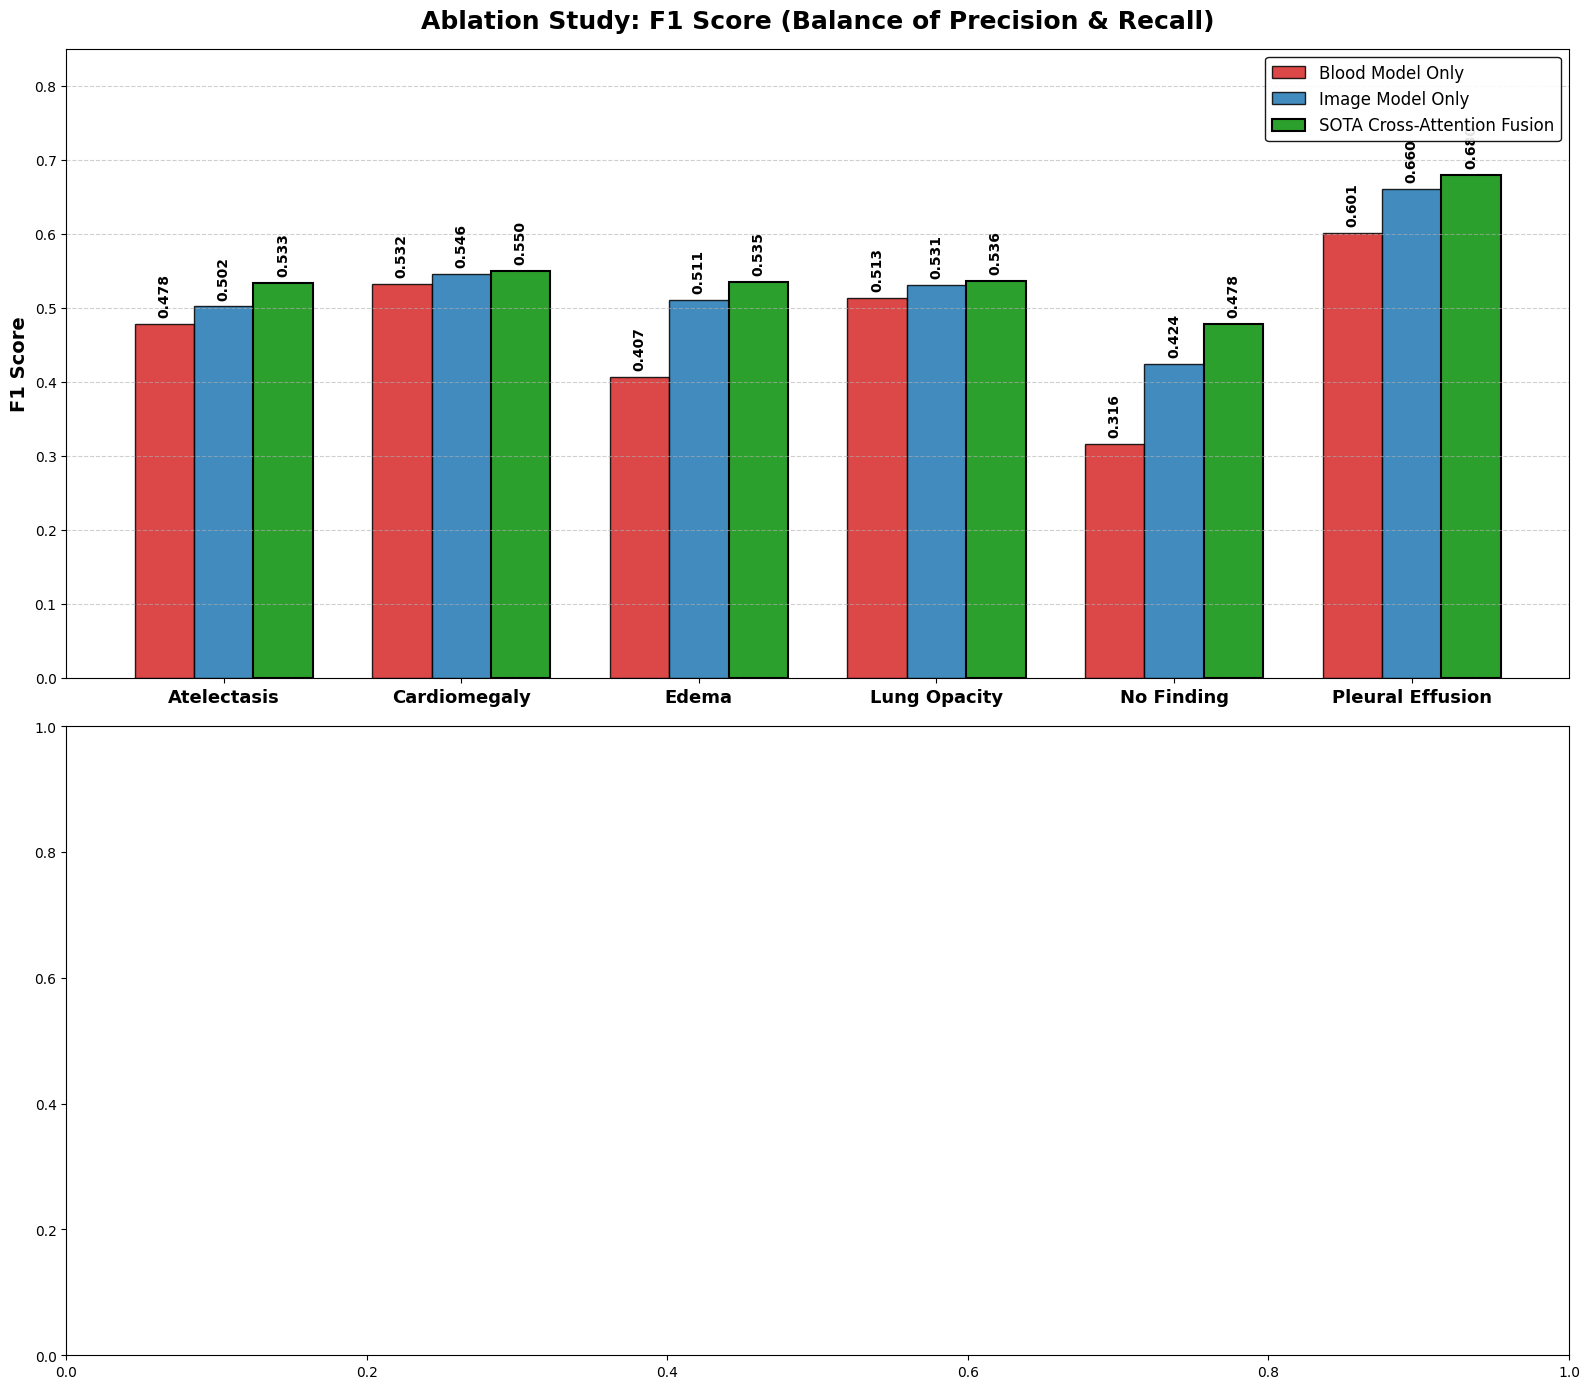

✅ F1 and Recall plots generated successfully!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, recall_score

# ==========================================
# DYNAMIC ABLATION: F1 SCORE & RECALL
# ==========================================
print("Calculating F1 and Recall using a clinical threshold of 0.40...")

# We use 0.40 because that was the optimal threshold discovered by your Grid Search
THRESHOLD = 0.40

# Convert raw probabilities into strict 0 or 1 predictions
pred_img = (y_img >= THRESHOLD).astype(int)
pred_tab = (y_tab >= THRESHOLD).astype(int)
pred_fus = (y_fus >= THRESHOLD).astype(int)

# Initialize lists to store our metrics
f1_img, f1_tab, f1_fus = [], [], []
rec_img, rec_tab, rec_fus = [], [], []

for i in range(len(target_cols)):
    # Calculate F1 Score
    f1_img.append(f1_score(y_true[:, i], pred_img[:, i], zero_division=0))
    f1_tab.append(f1_score(y_true[:, i], pred_tab[:, i], zero_division=0))
    f1_fus.append(f1_score(y_true[:, i], pred_fus[:, i], zero_division=0))

    # Calculate Recall
    rec_img.append(recall_score(y_true[:, i], pred_img[:, i], zero_division=0))
    rec_tab.append(recall_score(y_true[:, i], pred_tab[:, i], zero_division=0))
    rec_fus.append(recall_score(y_true[:, i], pred_fus[:, i], zero_division=0))

# ==========================================
# GENERATING THE DUAL-CHART
# ==========================================
print("Drawing plots...")
x = np.arange(len(target_cols))
width = 0.25

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))

# Helper function to put numbers on the bars
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points", ha='center', va='bottom',
                    fontsize=10, fontweight='bold', rotation=90)

# --- PLOT 1: F1 SCORE ---
rects1 = ax1.bar(x - width, f1_tab, width, label='Blood Model Only', color='#d62728', alpha=0.85, edgecolor='black')
rects2 = ax1.bar(x, f1_img, width, label='Image Model Only', color='#1f77b4', alpha=0.85, edgecolor='black')
rects3 = ax1.bar(x + width, f1_fus, width, label='SOTA Cross-Attention Fusion', color='#2ca02c', alpha=1.0, edgecolor='black', linewidth=1.5)

ax1.set_ylabel('F1 Score', fontsize=14, fontweight='bold')
ax1.set_title('Ablation Study: F1 Score (Balance of Precision & Recall)', fontsize=18, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(target_cols, fontsize=13, fontweight='bold')
ax1.set_ylim(0, 0.85)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
ax1.legend(loc='upper right', fontsize=12, framealpha=0.9, edgecolor='black')
autolabel(rects1, ax1)
autolabel(rects2, ax1)
autolabel(rects3, ax1)

# --- PLOT 2: RECALL (SENSITIVITY) ---
rects4 = ax2.bar(x - width, rec_tab, width, label='Blood Model Only', color='#d62728', alpha=0.85, edgecolor='black')
rects5 = ax2.bar(x, rec_img, width, label='Image Model Only', color='#1f77b4', alpha=0.85, edgecolor='black')
rects6 = ax2.bar(x + width, rec_fus, width, label='SOTA Cross-Attention Fusion', color='#2ca02c', alpha=1.0, edgecolor='black', linewidth=1.5)

ax2.set_ylabel('Recall Score', fontsize=14, fontweight='bold')
ax2.set_title('Ablation Study: Recall (Ability to Catch Sick Patients)', fontsize=18, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(target_cols, fontsize=13, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.grid(axis='y', linestyle='--', alpha=0.6)
ax2.legend(loc='upper right', fontsize=12, framealpha=0.9, edgecolor='black')
autolabel(rects4, ax2)
autolabel(rects5, ax2)
autolabel(rects6, ax2)

plt.tight_layout()
plt.savefig('Dynamic_Ablation_Study_F1_Recall.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ F1 and Recall plots generated successfully!")